<a href="https://colab.research.google.com/github/Ginkno/postech-tech-challenge-fase2-grupo1-12dtat/blob/Elizabeth/notebooks/%2001_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [206]:
#Libs - Bibliotecas importantes

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np


# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_1 = Path("../data/raw/application_record.csv")
RAW_2 = Path("../data/raw/credit_record.csv")


PROCESSED = Path("..") / "data" / "processed"
TARGET = "IS_BAD_PAYER"

pd.set_option("display.max_columns", None)

In [207]:
#Leitura do dataframe e visualização das cinco primeiras linhas.

df_application = pd.read_csv(RAW_1)
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Leitura do dataframe e visualização das cinco primeiras linhas.

## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [208]:
print(f"Tamanho do df_application: {df_application.shape}")

Tamanho do df_application: (438557, 18)


In [209]:
#Visualizar os tipos das variáveis.

df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

O df_application possui 438557 registros e 18 colunas. Ao analisar os tipos de dados com o comando .info(), observamos que há 02 variáveis tipo float, 8 tipo int e 08 como texto (tipo object).

In [210]:
#Verificando a existência de dados nulos.

df_application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

Verificando a existência de dados nulos e como resultado trouxe que a coluna OCCUPATION_TYPE possui 134203 linhas em branco.

In [211]:
#Substituir os dados em branco da variável OCCUPATION_TYPE por "Unknown".

df_application["OCCUPATION_TYPE"] = df_application["OCCUPATION_TYPE"].fillna("Unknown")

In [212]:
#Verificando a existência de dados duplicados.

df_application.duplicated().sum()

np.int64(0)

Verificando a existência de dados duplicados e como resultado trouxe que a quantidade de dados duplicados é 0.

In [213]:
print(f"Quantidade de IDs únicos em df_application: {df_application['ID'].nunique()}")

Quantidade de IDs únicos em df_application: 438510


In [214]:
#Verificando a existência de IDs duplicados.

df_application["ID"].duplicated().sum()

np.int64(47)

In [215]:
#Para os IDs duplicados, verificar se os dados das outras variáveis estão duplicados também.

duplicados = df_application[df_application["ID"].duplicated(keep=False)]
duplicados.sort_values(by="ID")


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,Unknown,1.0
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0
425486,7023108,M,Y,Y,1,67500.0,Working,Secondary / secondary special,Married,House / apartment,-15156,-1696,1,1,0,0,Core staff,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426563,7836711,F,N,Y,2,292500.0,Working,Higher education,Married,House / apartment,-13747,-4386,1,0,1,0,Accountants,4.0
428620,7836971,F,N,Y,0,103500.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-13383,-2798,1,0,1,0,Sales staff,2.0
421464,7836971,M,Y,N,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,-13771,-5520,1,0,0,0,Unknown,3.0
422068,7838075,M,N,Y,0,337500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18198,-1275,1,0,0,1,Drivers,2.0


Foram identificados 47 IDs repetidos com informações divergentes nas demais variáveis. Como não foi possível determinar qual registro representa a informação mais atual ou correta, optou-se por manter os registros para análise posterior.

In [216]:
# Lista de colunas sem a coluna ID

cols_sem_id = df_application.columns.drop('ID')

# Linhas consideradas duplicadas ignorando o ID

duplicadas = df_application[df_application.duplicated(subset=cols_sem_id, keep=False)]

print(f"Quantidade de linhas duplicadas (ignorando ID): {len(duplicadas)}")

duplicadas.sort_values(by=list(cols_sem_id))

Quantidade de linhas duplicadas (ignorando ID): 423253


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
273113,6093713,F,N,N,0,26100.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21003,365243,1,0,0,0,Unknown,2.0
436891,6093712,F,N,N,0,26100.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21003,365243,1,0,0,0,Unknown,2.0
92482,5369432,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
92483,5369433,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
92484,5369434,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84129,5342638,M,Y,Y,5,810000.0,Working,Secondary / secondary special,Married,House / apartment,-14914,-2593,1,0,0,0,Laborers,7.0
84130,5342639,M,Y,Y,5,810000.0,Working,Secondary / secondary special,Married,House / apartment,-14914,-2593,1,0,0,0,Laborers,7.0
20441,5061207,M,Y,Y,14,225000.0,Working,Secondary / secondary special,Separated,House / apartment,-17754,-1689,1,0,0,0,Drivers,15.0
20442,5061210,M,Y,Y,14,225000.0,Working,Secondary / secondary special,Separated,House / apartment,-17754,-1689,1,0,0,0,Drivers,15.0


In [217]:
#Quantas linhas são repetidas, ignorando a variável 'ID'.

df_application.duplicated(subset=df_application.columns.drop('ID')).sum()

np.int64(348472)

O resultado indica que existem 348.472 linhas com valores exatamente iguais nas demais colunas, mesmo que possuam IDs diferentes, porém não podemos determinar se são pessoas iguais ou diferentes. O fato de terem as mesmas características não as torna o mesmo cliente.

In [218]:
#Analisar a variável DAYS_EMPLOYED com o valor 365243.

(df_application["DAYS_EMPLOYED"] ==365243).sum()

np.int64(75329)

São 75329 linhas que aparecem o valor 365243. Conforme dicionário de dados disponibilizado significa pessoas desempregadas.

In [219]:
#Identificar padrão.

df_application.loc[df_application["DAYS_EMPLOYED"] == 365243, ["DAYS_EMPLOYED", "OCCUPATION_TYPE"]]

,DAYS_EMPLOYED,OCCUPATION_TYPE
7,365243,Unknown
8,365243,Unknown
9,365243,Unknown
76,365243,Unknown
160,365243,Unknown
...,...,...
438549,365243,Unknown
438550,365243,Unknown
438551,365243,Unknown
438552,365243,Unknown


Os dados nulos na variável OCCUPATION_TYPE foram substituídos por "Unknown". Código gerado para analisar a relação entre essas duas variáveis com o registro 365243.

In [220]:
#Identificar padrão.

df_application.loc[df_application["DAYS_EMPLOYED"] == 365243, "NAME_INCOME_TYPE",].value_counts()

NAME_INCOME_TYPE
Pensioner    75329
Name: count, dtype: int64

Ao analisar a variável DAYS_EMPLOYED, observou-se a ocorrência de 75.329 registros com o valor 365243. O cruzamento dessa informação com a variável NAME_INCOME_TYPE mostrou que todos esses registros correspondem à categoria Pensioner (aposentados/pensionistas). De acordo com o dicionário de dados da base, valores positivos em DAYS_EMPLOYED devem ser interpretados como indivíduos sem vínculo empregatício ativo. No entanto, é importante destacar que os pensionistas possuem uma fonte de renda previdenciária regular, o que os diferencia de indivíduos efetivamente desempregados. Portanto, o valor 365243 aparenta representar um código especial utilizado para identificar beneficiários de aposentadoria ou pensão, e não necessariamente a ausência de renda. Essa característica deve ser considerada durante as etapas de tratamento e interpretação dos dados para evitar conclusões equivocadas sobre a situação financeira desses clientes.

In [221]:
#Converter dias de nascimento para idade em anos e para inteiro.
df_application["YEARS_BIRTH"] = (df_application["DAYS_BIRTH"] / -365).astype(int)

#Criar a coluna IS_INACTIVE (1 para inativo, 0 para empregado).
df_application["IS_INACTIVE"] = (df_application["DAYS_EMPLOYED"] == 365243).astype(int)

#Converter dias de emprego para anos.
df_application["YEARS_EMPLOYED"] = (df_application["DAYS_EMPLOYED"] / -365 ).astype(int)

In [222]:
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8


In [223]:
# Contar quantas vezes o valor -1000 aparece em YEARS_EMPLOYED
count_minus_1000 = (df_application['YEARS_EMPLOYED'] == -1000).sum()
print(f"Quantidade de registros com YEARS_EMPLOYED == -1000: {count_minus_1000}")

# Verificar a relação entre YEARS_EMPLOYED == -1000 e IS_INACTIVE
print("Verificando se -1000 em YEARS_EMPLOYED corresponde a IS_INACTIVE == 1:")
display(df_application.loc[df_application['YEARS_EMPLOYED'] == -1000, 'IS_INACTIVE'].value_counts())

Quantidade de registros com YEARS_EMPLOYED == -1000: 75329
Verificando se -1000 em YEARS_EMPLOYED corresponde a IS_INACTIVE == 1:


IS_INACTIVE
1    75329
Name: count, dtype: int64

Como esperado, o valor `-1000` em `YEARS_EMPLOYED` corresponde exatamente aos registros onde `IS_INACTIVE` é `1`, ou seja, aos 'pensionistas/inativos'. Para facilitar a análise e a modelagem, substituiremos esse valor por `0`, indicando zero anos de emprego ativo, o que é consistente com a definição de inatividade.

In [224]:
# Substituir -1000 em YEARS_EMPLOYED por 0
df_application['YEARS_EMPLOYED'] = df_application['YEARS_EMPLOYED'].replace(-1000, 0)

# Verificar as primeiras linhas após a substituição
print("df_application.head() após substituição de -1000 por 0:")
display(df_application.head())

df_application.head() após substituição de -1000 por 0:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8


In [225]:
#Leitura do dataframe e visualização das cinco primeiras linhas.
df_credit = pd.read_csv(RAW_2)
df_credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


Conforme dicionário de dados disponibilizado: 0: 1-29 dias atrasados; 1: 30-59 dias atrasados; 2: 60-89 dias atrasados; 3: 90-119 dias atrasados; 4: 120-149 dias atrasados; 5: dívidas atrasadas ou incobráveis, perdas por mais de 150 dias; C: quitadas naquele mês; X: sem empréstimo no mês;

In [226]:
print(f"Tamanho do df_credit: {df_credit.shape}")

Tamanho do df_credit: (1048575, 3)


In [227]:
#Visualizar os tipos das variáveis.

df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


O df_credit possui 1048575 registros e 03 colunas. Ao analisar os tipos de dados com o comando .info(), observamos que há 02 variáveis tipo int e 01 como texto (tipo object).

In [228]:
#Verificando a existência de dados nulos.

df_credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

Como resultado trouxe que a quantidade de dados nulos é 0.

In [229]:
#Verificando a existência de dados duplicados.

df_credit.duplicated().sum()

np.int64(0)

Como resultado trouxe que a quantidade de dados duplicados é 0.

In [230]:
#Verificando a existência de IDs duplicados.

df_credit["ID"].duplicated().sum()

np.int64(1002590)

Como resultado trouxe a quantidade 1002590 cópias.

In [231]:
duplicados = df_credit[df_credit["ID"].duplicated(keep=False)]
duplicados.sort_values(by="ID")

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048562,5150487,-17,C
1048569,5150487,-24,C
1048567,5150487,-22,C
1048568,5150487,-23,C


1048176 representa o total de linhas que contem IDs que aparecem mais de uma vez, incluindo a primeira ocorrência de cada ID duplicado. Porém referem-se a meses diferentes.

In [232]:
print(df_credit['ID'].nunique())
print(len(df_credit))

45985
1048575


45985 IDs únicos do total de 1048575 IDs.

Para unir as informações de df_credit com as de df_application, é preciso consolidar o histórico de crédito de cada cliente (ID) em uma única linha.

Codificar a variável STATUS: Atribuir valores numéricos que reflitam o risco de crédito. Agregar por ID: Para cada cliente, obter a pontuação de risco máximo (pior status) e o número de meses no histórico (MONTHS_BALANCE).

In [233]:
# Criar uma cópia de df_credit para evitar modificar o original
df_status_agreggated = df_credit.copy()
# -------------------------------------------------------------------------
# 1. Mapeamento do Status para nível numérico de atraso
# -------------------------------------------------------------------------
# Consideramos atraso real os status 0, 1, 2, 3, 4, 5.
# X e C representam sem dívida / em dia (nível 0 de atraso).
status_map = {"X": 0, "C": 0, "0": 1, "1": 2, "2": 3, "3": 4, "4": 5, "5": 6}

# Garante texto limpo do status original
df_status_agreggated["STATUS_ORIGINAL"] = (
    df_status_agreggated["STATUS"].astype(str).str.strip()
)

# Cria a coluna numérica para gravidade do atraso (ex: WORST_LATE)
df_status_agreggated["STATUS_NUM"] = (
    df_status_agreggated["STATUS_ORIGINAL"]
    .map(status_map)
    .fillna(0)
    .astype(int)
)

# Flag booleana: verifica os caracteres ORIGINAIS do status que representam atraso
df_status_agreggated["IS_LATE"] = df_status_agreggated[
    "STATUS_ORIGINAL"
].isin(["0", "1", "2", "3", "4", "5"])
# -------------------------------------------------------------------------
# 2. Filtragem de janelas de tempo (últimos N meses)
# -------------------------------------------------------------------------
# Como months_balance vai de 0 (mais recente) a negativos (-1, -2, ...),
# filtramos pelo valor absoluto do mês.
df_3m = df_status_agreggated[df_status_agreggated["MONTHS_BALANCE"] >= -2]  # Últimos 3 meses (0, -1, -2)
df_6m = df_status_agreggated[df_status_agreggated["MONTHS_BALANCE"] >= -5]  # Últimos 6 meses
df_9m = df_status_agreggated[df_status_agreggated["MONTHS_BALANCE"] >= -8]  # Últimos 9 meses
df_12m = df_status_agreggated[df_status_agreggated["MONTHS_BALANCE"] >= -11]  # Últimos 12 meses

# -------------------------------------------------------------------------
# 3. Criação das flags de atraso nas janelas (0 ou 1)
# -------------------------------------------------------------------------
late_3m = df_3m.groupby("ID")["IS_LATE"].any().astype(int).rename("LATE_3M")
late_6m = df_6m.groupby("ID")["IS_LATE"].any().astype(int).rename("LATE_6M")
late_9m = df_9m.groupby("ID")["IS_LATE"].any().astype(int).rename("LATE_9M")
late_12m = df_12m.groupby("ID")["IS_LATE"].any().astype(int).rename("LATE_12M")

# -------------------------------------------------------------------------
# 4. Pior histórico de atraso (WORST_LATE)
# -------------------------------------------------------------------------
# Pega o maior nível numérico de atraso e mapeia de volta para a flag original
worst_num = df_status_agreggated.groupby("ID")["STATUS_NUM"].max()
num_to_status = {0: "C", 1: "0", 2: "1", 3: "2", 4: "3", 5: "4", 6: "5"}
worst_late = worst_num.map(num_to_status).rename("WORST_LATE")

# -------------------------------------------------------------------------
# 5. Recência do último atraso (LAST_LATE)
# -------------------------------------------------------------------------
# Filtramos apenas as linhas onde houve atraso e pegamos o mês mais recente (max no MONTHS_BALANCE)
df_lates_only = df_status_agreggated[df_status_agreggated["IS_LATE"] == True]
last_late_month = df_lates_only.groupby("ID")["MONTHS_BALANCE"].max()

# A distância em meses até o presente (mês 0) é |MONTHS_BALANCE|
# Se o cliente nunca atrasou, atribuímos um valor alto (ex: 999 ou NaN)
last_late = (last_late_month.abs()).rename("LAST_LATE")

# Total de meses de histórico do cliente
hist_length = (
    df_status_agreggated.groupby("ID")["MONTHS_BALANCE"].count().rename("HIST_LENGTH")
)

# Total absoluto de meses com atraso (Substitui com vantagem a métrica fracionária)
total_lates = df_status_agreggated.groupby("ID")["IS_LATE"].sum().rename("TOTAL_LATES")

# Proporção de meses com atraso (de 0.0 a 1.0)
late_rate = (total_lates / hist_length).rename("LATE_RATE")

# -------------------------------------------------------------------------
# 7. Consolidação em um DataFrame final único por ID
# -------------------------------------------------------------------------
# Pega a lista única de todos os IDs
df_features_behavior = pd.DataFrame(index=df_status_agreggated["ID"].unique()).sort_index()

# Unindo todas as métricas geradas
df_features_behavior = df_features_behavior.join(
    [late_3m, late_6m, late_9m, late_12m, worst_late, last_late, hist_length, total_lates, late_rate]
)

# Trata clientes sem histórico em janelas específicas ou sem atraso
df_features_behavior["LATE_3M"] = df_features_behavior["LATE_3M"].fillna(0).astype(int)
df_features_behavior["LATE_6M"] = df_features_behavior["LATE_6M"].fillna(0).astype(int)
df_features_behavior["LATE_9M"] = df_features_behavior["LATE_9M"].fillna(0).astype(int)
df_features_behavior["LATE_12M"] = df_features_behavior["LATE_12M"].fillna(0).astype(int)
df_features_behavior["WORST_LATE"] = df_features_behavior["WORST_LATE"].fillna("C")
df_features_behavior["LAST_LATE"] = df_features_behavior["LAST_LATE"].fillna(
    999
)  # 999 = Nunca atrasou

# Resetando o índice para deixar a coluna 'ID' normal
df_features_behavior = df_features_behavior.reset_index().rename(columns={"index": "ID"})

# Exibe os primeiros resultados
print("Histórico consolidado")
df_features_behavior.head(10)


Histórico consolidado


,ID,LATE_3M,LATE_6M,LATE_9M,LATE_12M,WORST_LATE,LAST_LATE,HIST_LENGTH,TOTAL_LATES,LATE_RATE
0,5001711,1,1,1,1,0,1.0,4,3,0.750000
1,5001712,0,0,0,1,0,9.0,19,10,0.526316
2,5001713,0,0,0,0,C,999.0,22,0,0.000000
3,5001714,0,0,0,0,C,999.0,15,0,0.000000
4,5001715,0,0,0,0,C,999.0,60,0,0.000000
5,5001717,0,1,1,1,0,5.0,22,17,0.772727
6,5001718,0,1,1,1,1,3.0,39,26,0.666667
7,5001719,0,0,0,0,0,41.0,43,2,0.046512
8,5001720,1,1,1,1,1,0.0,36,36,1.000000
9,5001723,0,0,0,0,0,22.0,31,8,0.258065


In [234]:
# Mesclar df_application com df_features_behavior usando a coluna 'ID'
df_final = pd.merge(df_application, df_features_behavior, on='ID', how='inner')

# Exibir as primeiras linhas do dataframe final
print("Primeiras 5 linhas do df_final:")
display(df_final.head())

# Exibir o formato do dataframe final
print(f"Dimensão do df_final: {df_final.shape}")

Primeiras 5 linhas do df_final:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED,LATE_3M,LATE_6M,LATE_9M,LATE_12M,WORST_LATE,LAST_LATE,HIST_LENGTH,TOTAL_LATES,LATE_RATE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12,0,0,0,0,1,13.0,16,2,0.125000
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12,0,0,0,0,1,12.0,15,2,0.133333
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3,0,0,1,1,0,8.0,30,7,0.233333
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8,1,1,1,1,0,0.0,5,2,0.400000
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8,0,0,0,0,C,999.0,5,0,0.000000


Dimensão do df_final: (36457, 30)


In [235]:
df_features_behavior["WORST_LATE"].value_counts()  

WORST_LATE
0    34682
C     5953
1     4683
2      336
5      195
3       88
4       48
Name: count, dtype: int64

In [236]:
# Verificar informações gerais do df_final
print("\nInformações do df_final:")
df_final.info()


Informações do df_final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL

In [237]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,36457.0,5.078227e+06,41875.240788,5008804.0,5.042028e+06,5.074614e+06,5.115396e+06,5150487.0
CNT_CHILDREN,36457.0,4.303152e-01,0.742367,0.0,0.000000e+00,0.000000e+00,1.000000e+00,19.0
AMT_INCOME_TOTAL,36457.0,1.866857e+05,101789.226482,27000.0,1.215000e+05,1.575000e+05,2.250000e+05,1575000.0
DAYS_BIRTH,36457.0,-1.597517e+04,4200.549944,-25152.0,-1.943800e+04,-1.556300e+04,-1.246200e+04,-7489.0
DAYS_EMPLOYED,36457.0,5.926294e+04,137651.334859,-15713.0,-3.153000e+03,-1.552000e+03,-4.080000e+02,365243.0
FLAG_MOBIL,36457.0,1.000000e+00,0.000000,1.0,1.000000e+00,1.000000e+00,1.000000e+00,1.0
FLAG_WORK_PHONE,36457.0,2.255260e-01,0.417934,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.0
FLAG_PHONE,36457.0,2.948131e-01,0.455965,0.0,0.000000e+00,0.000000e+00,1.000000e+00,1.0
FLAG_EMAIL,36457.0,8.972214e-02,0.285787,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.0
CNT_FAM_MEMBERS,36457.0,2.198453e+00,0.911686,1.0,2.000000e+00,2.000000e+00,3.000000e+00,20.0


## 2. Distribuição das variáveis

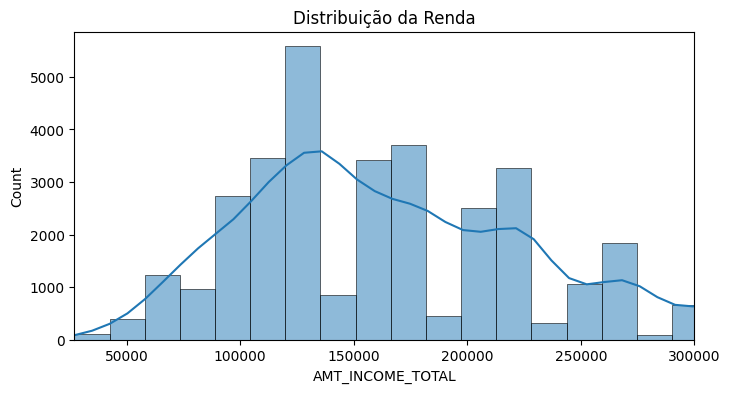

In [238]:
#Histograma para AMT_INCOME_TOTAL.

plt.figure(figsize=(8,4))
sns.histplot(df_final["AMT_INCOME_TOTAL"], kde=True, bins=100)
plt.title("Distribuição da Renda")
plt.xlim(27000, 300000)
plt.show()

O histograma da **Distribuição da Renda (AMT_INCOME_TOTAL)** mostra uma concentração de indivíduos nas faixas de renda mais baixas e médias. Há picos notáveis em torno de 120.000 e 180.000, e a distribuição tende a ser assimétrica positiva (cauda longa à direita), indicando a presença de algumas rendas mais elevadas.

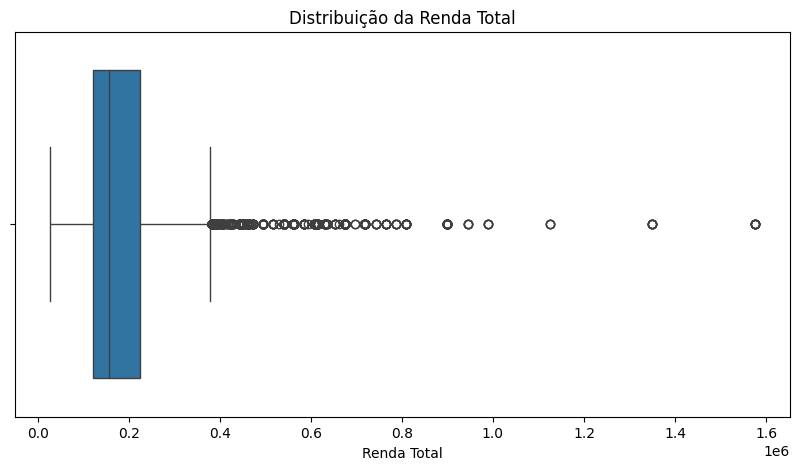

In [239]:
#Boxplot para AMT_INCOME_TOTAL.

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final["AMT_INCOME_TOTAL"])
plt.title("Distribuição da Renda Total")
plt.xlabel("Renda Total")
plt.show()

O *boxplot* da **Distribuição da Renda Total (AMT_INCOME_TOTAL)** corrobora a assimetria observada no histograma, com uma grande concentração de dados na parte inferior da caixa. A presença de vários pontos individuais fora dos 'bigodes' do *boxplot* à direita indica a existência de *outliers*, ou seja, pessoas com rendas significativamente mais altas que a maioria.

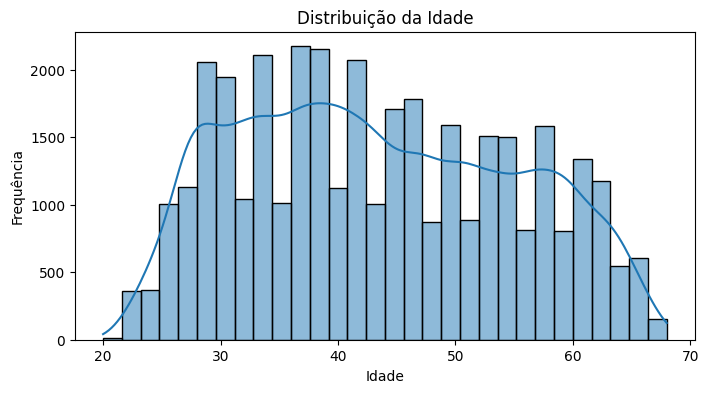

In [240]:
#Histograma para YEARS_BIRTH.
plt.figure(figsize=(8,4))
sns.histplot(df_final["YEARS_BIRTH"], kde=True, bins=30)
plt.title("Distribuição da Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

O histograma da **Distribuição da Idade (YEARS_BIRTH)** revela que a maior parte dos solicitantes está na faixa dos 30 a 40 anos, com uma distribuição que se assemelha a uma curva normal, mas com um leve pico em idades mais jovens. Há uma diminuição gradual na frequência conforme a idade avança.

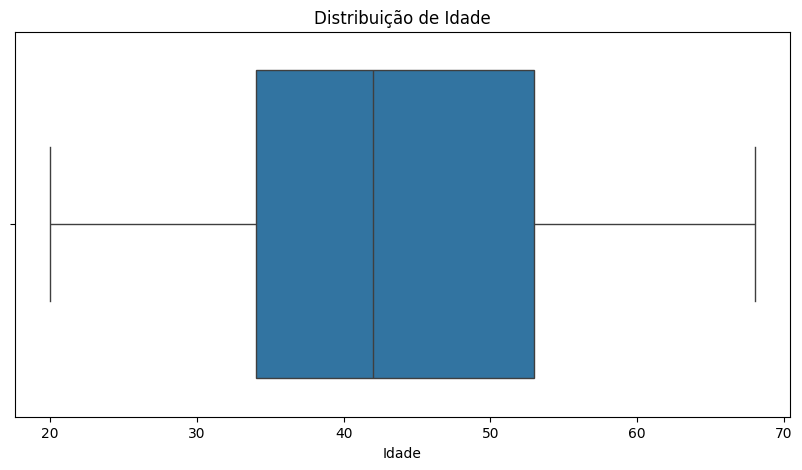

In [241]:
#Boxplot para YEARS_BIRTH

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final["YEARS_BIRTH"])
plt.title("Distribuição de Idade")
plt.xlabel("Idade")
plt.show()

O *boxplot* da **Distribuição de Idade (YEARS_BIRTH)** mostra que a idade mediana dos solicitantes está em torno de 42 anos. A maior parte dos dados (entre o 1º e 3º quartil) está concentrada entre aproximadamente 34 e 53 anos. Não há *outliers* visíveis neste gráfico, indicando que as idades se mantêm dentro de um intervalo esperado.

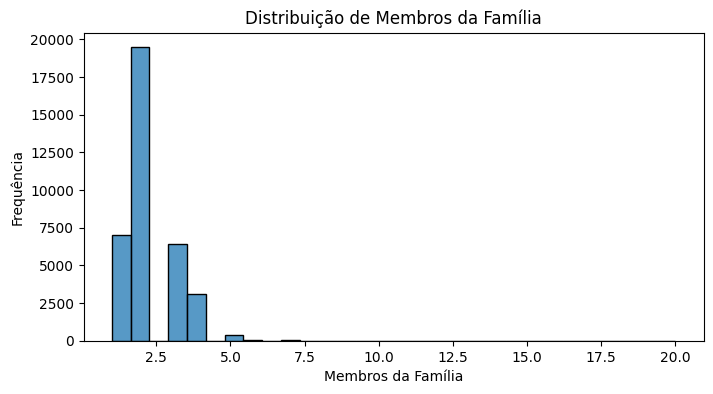

In [242]:
#Histograma para CNT_FAM_MEMBERS.
plt.figure(figsize=(8,4))
sns.histplot(df_final["CNT_FAM_MEMBERS"], bins =30)
plt.title("Distribuição de Membros da Família")
plt.xlabel("Membros da Família")
plt.ylabel("Frequência")
plt.show()

O histograma da **Distribuição de Membros da Família (CNT_FAM_MEMBERS)** indica que a maioria dos solicitantes tem 2 membros na família, seguido por 1 membro e 3 membros. Famílias maiores (com 4 ou mais membros) são menos frequentes. Existem alguns poucos casos de famílias muito grandes, representados como barras pequenas à direita.

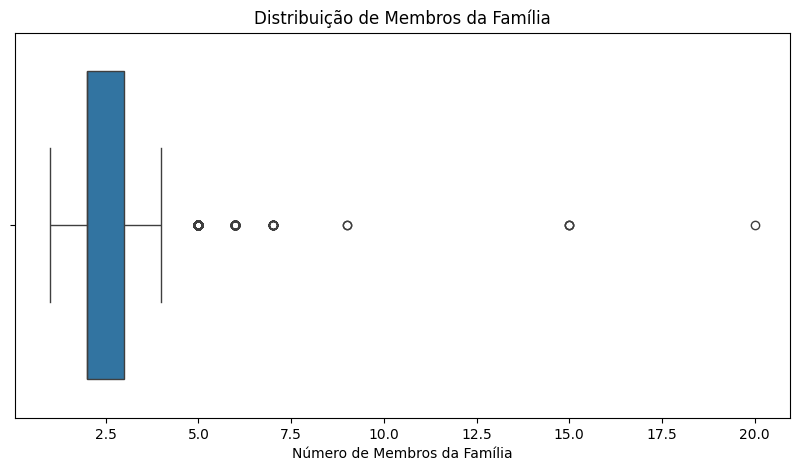

In [243]:
#Boxplot para CNT_FAM_MEMBERS

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final["CNT_FAM_MEMBERS"])
plt.title("Distribuição de Membros da Família")
plt.xlabel("Número de Membros da Família")
plt.show()

O *boxplot* da **Distribuição de Membros da Família (CNT_FAM_MEMBERS)** confirma que a maioria das famílias tem 2 membros (mediana). A maior parte dos dados está entre 2 e 3 membros. Há alguns *outliers* à direita, representando famílias com um número excepcionalmente alto de membros.

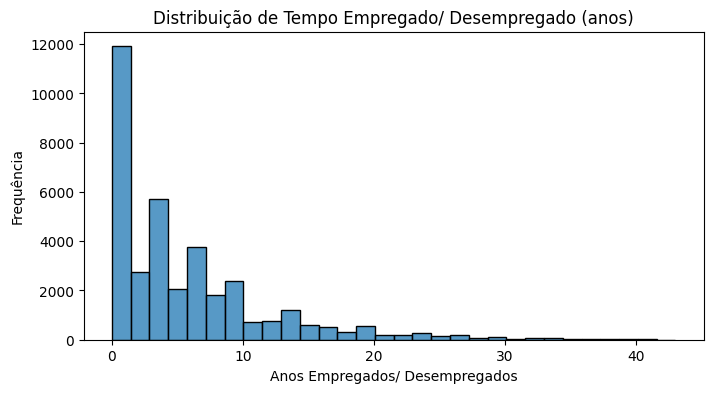

In [244]:
#Histograma para YEARS_EMPLOYED.

plt.figure(figsize=(8,4))
sns.histplot(df_final["YEARS_EMPLOYED"], bins=30)
plt.title("Distribuição de Tempo Empregado/ Desempregado (anos)")
plt.xlabel("Anos Empregados/ Desempregados")
plt.ylabel("Frequência")
plt.show()

O histograma da **Distribuição de Tempo Empregado/Desempregado (YEARS_EMPLOYED)** mostra um pico significativo em 0 anos, que corresponde aos indivíduos inativos/pensionistas que tiveram o valor de -1000 substituído por 0. A partir daí, a distribuição decai rapidamente, indicando que a maioria dos empregados tem poucos anos de serviço, e um número menor de indivíduos possui mais anos de experiência.

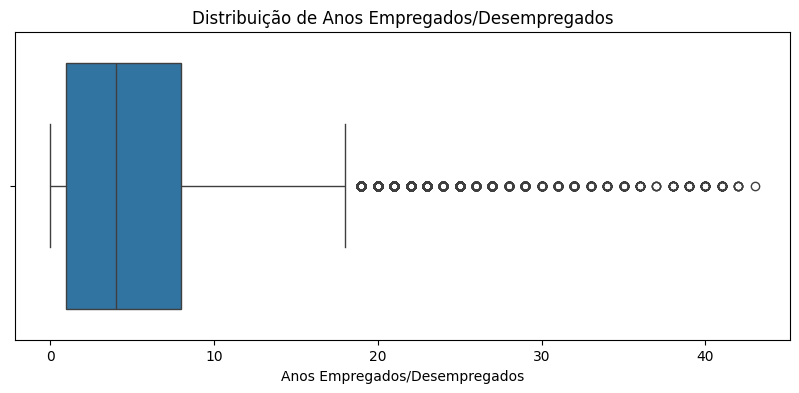

In [245]:
#Boxplot para YEARS_EMPLOYED

plt.figure(figsize=(10,4))
sns.boxplot(x=df_final["YEARS_EMPLOYED"])
plt.title("Distribuição de Anos Empregados/Desempregados")
plt.xlabel("Anos Empregados/Desempregados")
plt.show()

O *boxplot* da **Distribuição de Anos Empregados/Desempregados (YEARS_EMPLOYED)**, após o tratamento do valor -1000 para 0, mostra uma mediana baixa (em torno de 4 anos). A maior parte dos dados (entre o 1º e 3º quartil) está concentrada nos primeiros anos de emprego. Há muitos *outliers* à direita, indicando indivíduos com longos períodos de emprego, o que é esperado, já que alguns têm mais de 40 anos de experiência.

/tmp/ipykernel_5222/1080384511.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="IS_INACTIVE", order=[0,1], palette='viridis')


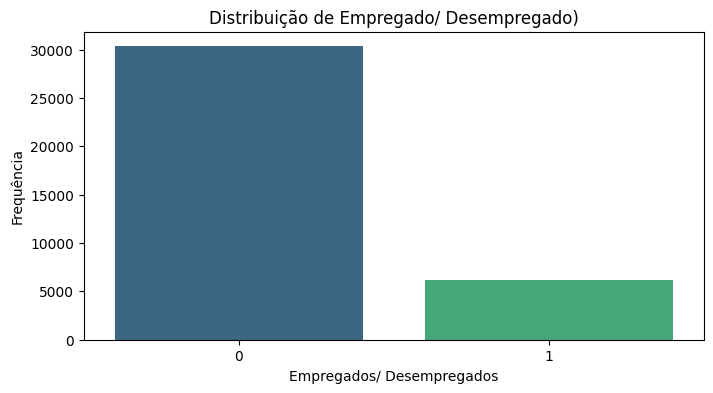

In [246]:
##Distribuição para IS_INACTIVE

plt.figure(figsize=(8,4))
sns.countplot(data=df_final, x="IS_INACTIVE", order=[0,1], palette='viridis')
plt.title("Distribuição de Empregado/ Desempregado)")
plt.xlabel("Empregados/ Desempregados")
plt.ylabel("Frequência")
plt.show()




O gráfico da **Distribuição de Empregado/Desempregado (IS_INACTIVE)** mostra claramente que a maioria dos solicitantes está ativa (0), enquanto uma parcela menor é inativa (1), confirmando a proporção de pensionistas/inativos identificada anteriormente.

/tmp/ipykernel_5222/892004808.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="CODE_GENDER", order=df_final["CODE_GENDER"].value_counts().index, palette='viridis')


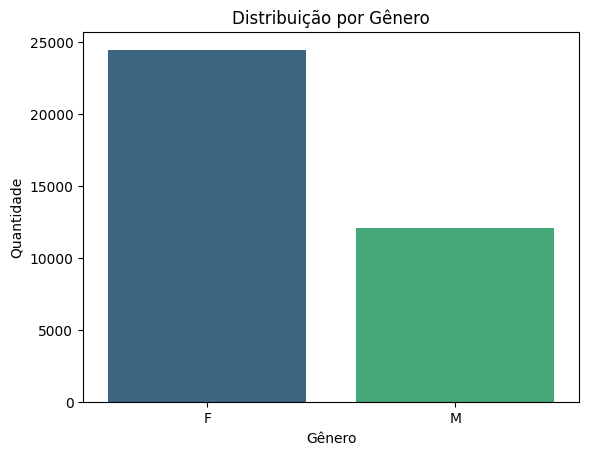

In [247]:
#Distribuição para CODE_GENDER

sns.countplot(data=df_final, x="CODE_GENDER", order=df_final["CODE_GENDER"].value_counts().index, palette='viridis')
plt.title("Distribuição por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")
plt.show()


O gráfico da **Distribuição por Gênero (CODE_GENDER)** indica que a base de dados possui significativamente mais mulheres ('F') do que homens ('M').

/tmp/ipykernel_5222/2314878658.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="OCCUPATION_TYPE", order=df_final["OCCUPATION_TYPE"].value_counts().index, palette='viridis')


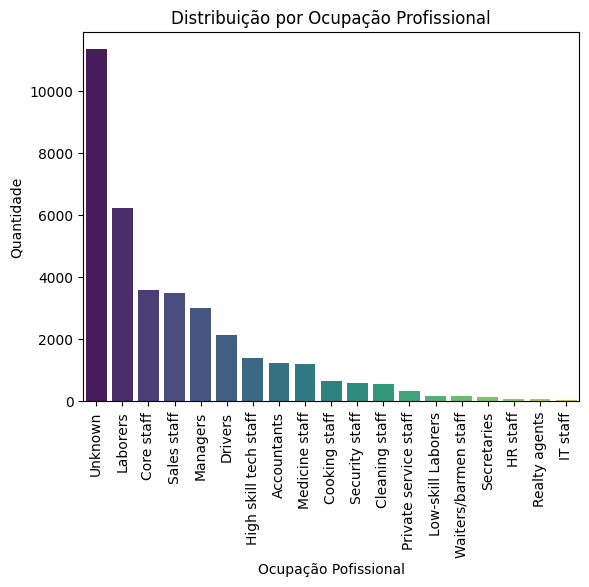

In [248]:
#Distribuição para OCCUPATION_TYPE.

sns.countplot(data=df_final, x="OCCUPATION_TYPE", order=df_final["OCCUPATION_TYPE"].value_counts().index, palette='viridis')
plt.title("Distribuição por Ocupação Profissional")
plt.xlabel("Ocupação Pofissional")
plt.xticks(rotation=90)
plt.ylabel("Quantidade")
plt.show()


O gráfico da **Distribuição por Ocupação Profissional (OCCUPATION_TYPE)** destaca que a categoria 'Unknown' (desconhecido, que preenche os valores nulos) é a mais frequente, seguida por 'Laborers' e 'Core staff'. Isso sugere que há muitos dados de ocupação ausentes ou não especificados.

/tmp/ipykernel_5222/3317911779.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="NAME_INCOME_TYPE", order=df_final["NAME_INCOME_TYPE"].value_counts().index, palette="viridis")


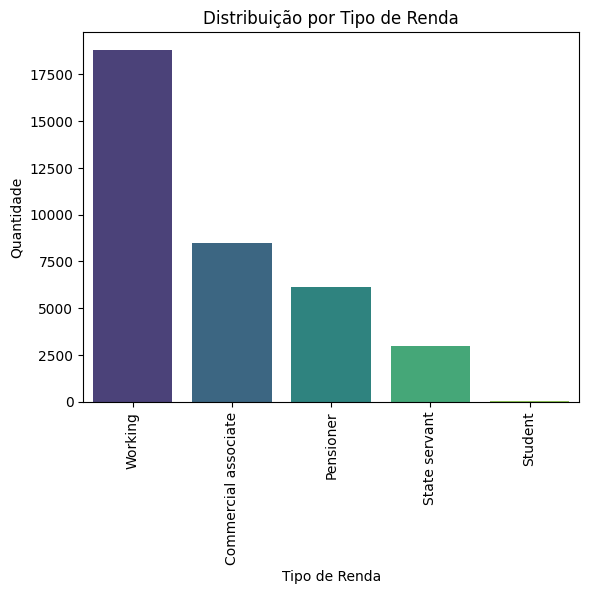

In [249]:
#Distribuição para NAME_INCOME_TYPE.

sns.countplot(data=df_final, x="NAME_INCOME_TYPE", order=df_final["NAME_INCOME_TYPE"].value_counts().index, palette="viridis")
plt.title("Distribuição por Tipo de Renda")
plt.xlabel("Tipo de Renda")
plt.xticks(rotation=90)
plt.ylabel("Quantidade")
plt.show()

A **Distribuição por Tipo de Renda (NAME_INCOME_TYPE)** mostra que a categoria 'Working' (trabalhadores ativos) é a mais predominante, seguida por 'Commercial associate' e 'Pensioner'. Isso reflete a composição da base de dados, com a maioria dos indivíduos tendo renda advinda de trabalho formal.

/tmp/ipykernel_5222/1614703125.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="FLAG_OWN_CAR", order=df_final["FLAG_OWN_CAR"].value_counts().index, palette="viridis")


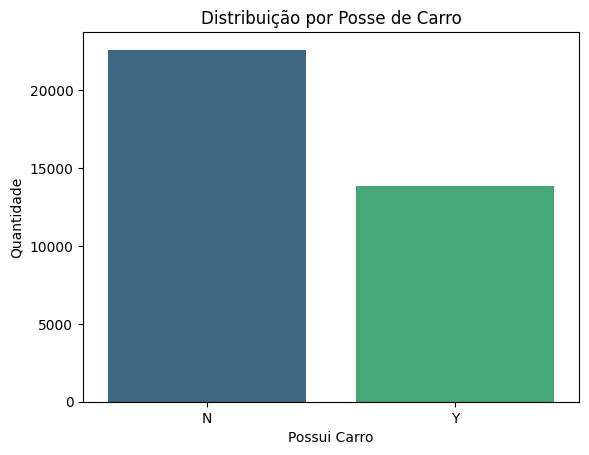

In [250]:
#Distribuição para FLAG_OWN_CAR.

sns.countplot(data=df_final, x="FLAG_OWN_CAR", order=df_final["FLAG_OWN_CAR"].value_counts().index, palette="viridis")
plt.title("Distribuição por Posse de Carro")
plt.xlabel("Possui Carro")
plt.ylabel("Quantidade")
plt.show()

O gráfico da **Distribuição por Posse de Carro (FLAG_OWN_CAR)** indica que a maioria dos solicitantes não possui carro ('N'), enquanto uma parte menor possui ('Y').

/tmp/ipykernel_5222/4159014428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="FLAG_OWN_REALTY", order=df_final["FLAG_OWN_REALTY"].value_counts().index, palette="viridis")


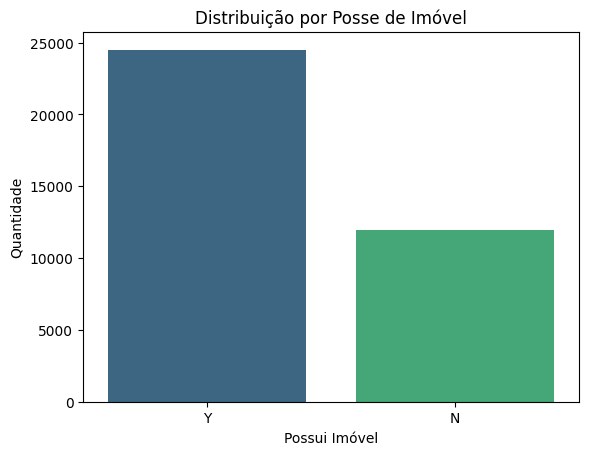

In [251]:
#Distribuição para FLAG_OWN_REALTY.

sns.countplot(data=df_final, x="FLAG_OWN_REALTY", order=df_final["FLAG_OWN_REALTY"].value_counts().index, palette="viridis")
plt.title("Distribuição por Posse de Imóvel")
plt.xlabel("Possui Imóvel")
plt.ylabel("Quantidade")
plt.show()

A **Distribuição por Posse de Imóvel (FLAG_OWN_REALTY)** mostra que a maioria dos indivíduos possui imóvel ('Y'), superando aqueles que não possuem ('N').

/tmp/ipykernel_5222/145525068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="NAME_EDUCATION_TYPE", order=df_final["NAME_EDUCATION_TYPE"].value_counts().index, palette="viridis")


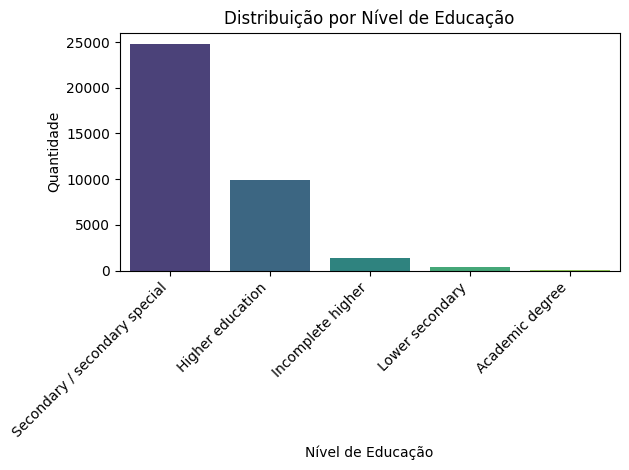

In [252]:
#Distribuição para NAME_EDUCATION_TYPE.
sns.countplot(data=df_final, x="NAME_EDUCATION_TYPE", order=df_final["NAME_EDUCATION_TYPE"].value_counts().index, palette="viridis")
plt.title("Distribuição por Nível de Educação")
plt.xlabel("Nível de Educação")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

O gráfico da **Distribuição por Nível de Educação (NAME_EDUCATION_TYPE)** evidencia que a maior parte dos solicitantes possui 'Secondary / secondary special' (ensino médio/técnico), seguido por 'Higher education' (ensino superior). Os demais níveis de escolaridade têm representação bem menor.

/tmp/ipykernel_5222/2645633963.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="NAME_HOUSING_TYPE", order=df_final["NAME_HOUSING_TYPE"].value_counts().index, palette="viridis")


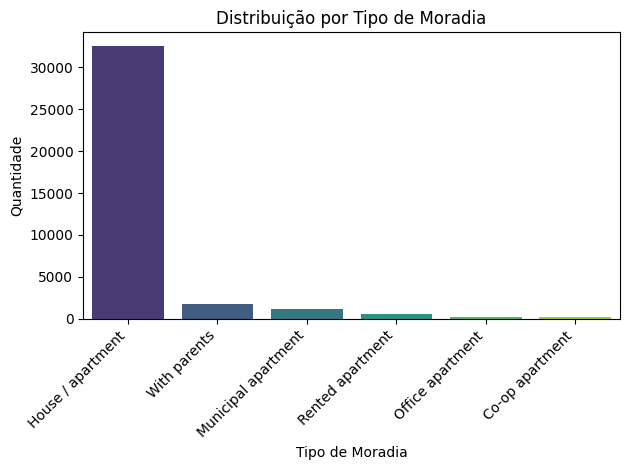

In [253]:
#Distribuição para NAME_HOUSING_TYPE.
sns.countplot(data=df_final, x="NAME_HOUSING_TYPE", order=df_final["NAME_HOUSING_TYPE"].value_counts().index, palette="viridis")
plt.title("Distribuição por Tipo de Moradia")
plt.xlabel("Tipo de Moradia")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

O gráfico da **Distribuição por Tipo de Moradia (NAME_HOUSING_TYPE)** aponta que 'House / apartment' (casa/apartamento) é o tipo de moradia esmagadoramente dominante entre os solicitantes, com outros tipos como 'With parents' ou 'Municipal apartment' sendo muito menos comuns.

#######################

In [254]:
#Histograma para TOTAL_MOUNTHS_OBSERVED.
plt.figure(figsize=(8,4))
sns.histplot(df_final["TOTAL_MOUNTHS_OBSERVED"], bins=15)
plt.title('Distribuição do Total de Meses Observados')
plt.xlabel('Quantidade Total de Meses Observados')
plt.ylabel('Frequência')
plt.show()

KeyError: 'TOTAL_MOUNTHS_OBSERVED'

<Figure size 800x400 with 0 Axes>

O histograma da **Distribuição do Total de Meses Observados (TOTAL_MOUNTHS_OBSERVED)** mostra que a maioria dos indivíduos tem um histórico de crédito observado por um período mais curto (entre 0 e 15 meses), com a frequência diminuindo conforme o número de meses observados aumenta. Isso sugere que muitos clientes são relativamente 'novos' no registro de crédito ou que o período de observação foi limitado para alguns.

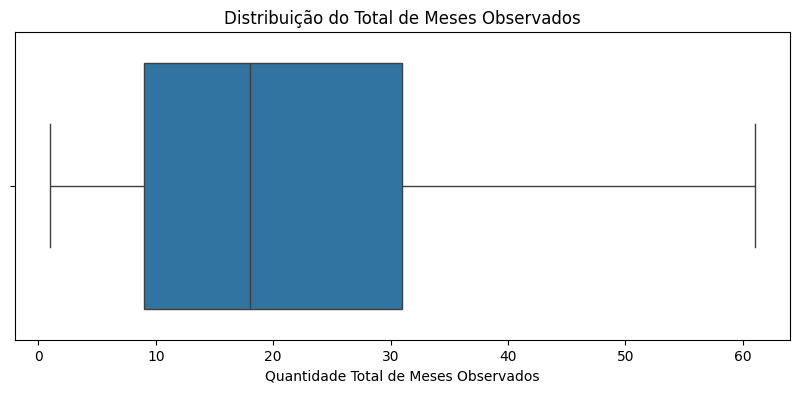

In [ ]:
#Boxplot para TOTAL_MOUNTHS_OBSERVED.

plt.figure(figsize=(10,4))
sns.boxplot(x=df_final["TOTAL_MONTHS_OBSERVED"])
plt.title("Distribuição do Total de Meses Observados")
plt.xlabel("Quantidade Total de Meses Observados")
plt.show()

O *boxplot* da **Distribuição do Total de Meses Observados (TOTAL_MOUNTHS_OBSERVED)** confirma que a mediana dos meses observados é de cerca de 18. A maior parte dos dados está concentrada entre aproximadamente 9 e 31 meses. Não há *outliers* evidentes, indicando uma distribuição contínua do tempo de observação.

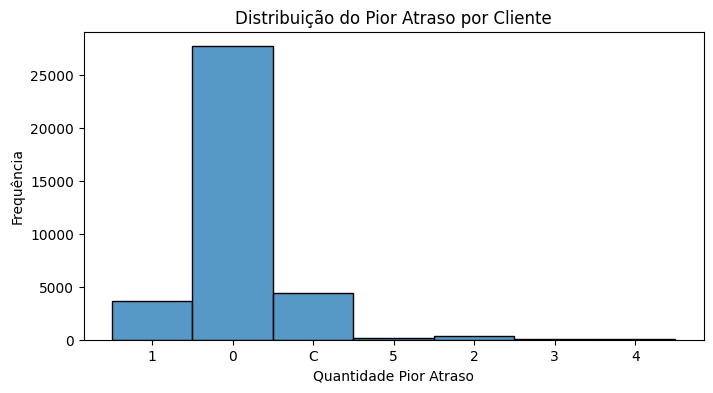

In [ ]:
#Histograma para STATUS_LATED.
plt.figure(figsize=(8,4))
sns.histplot(df_final["WORST_LATE"])
plt.title('Distribuição do Pior Atraso por Cliente')
plt.xlabel('Quantidade Pior Atraso')
plt.ylabel('Frequência')
plt.show()

O histograma da **Distribuição do Pior Atraso (WORST_LATE)** revela que a grande maioria dos clientes possui um número baixo de atrasos (entre 1 e 5). Há uma concentração no valor 0, indicando muitos clientes com atrasos de 1 mês apenas. Conforme o número de atrasos aumenta, a frequência diminui drasticamente, mostrando que poucos clientes acumulam muitos atrasos.

/tmp/ipykernel_5222/2708736565.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5222/2708736565.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


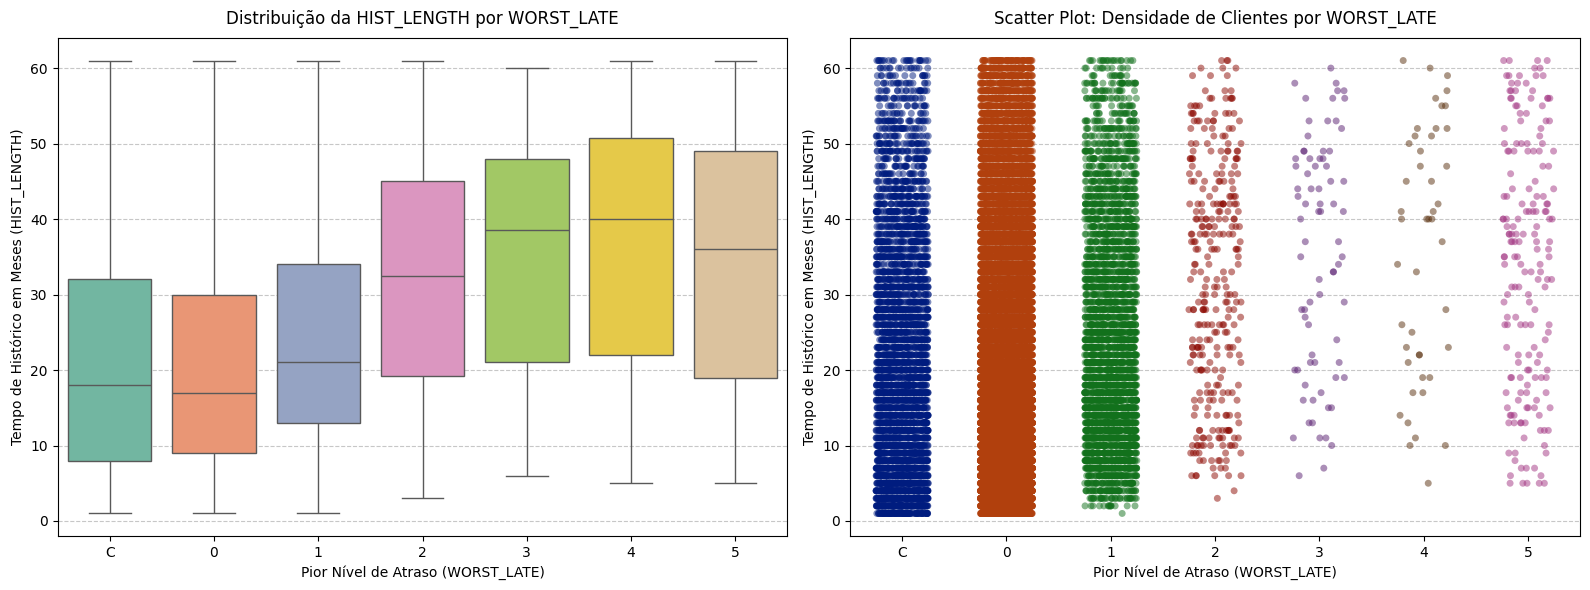

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Definir a ordem correta das categorias do pior atraso no eixo X
order_worst = ["X", "C", "0", "1", "2", "3", "4", "5"]
labels_worst = [
    "X\n(Sem Crédito)",
    "C\n(Em Dia)",
    "0\n(1-29d)",
    "1\n(30-59d)",
    "2\n(60-89d)",
    "3\n(90-119d)",
    "4\n(120-149d)",
    "5\n(150d+)",
]

# Configurar a figura com 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------------
# Gráfico 1: Boxplot da Distribuição de HIST_LENGTH por WORST_LATE
# -------------------------------------------------------------------------
sns.boxplot(
    data=df_final,
    x="WORST_LATE",
    y="HIST_LENGTH",
    order=[c for c in order_worst if c in df_final["WORST_LATE"].unique()],
    palette="Set2",
    ax=axes[0],
)

axes[0].set_title(
    "Distribuição da HIST_LENGTH por WORST_LATE", fontsize=12, pad=10
)
axes[0].set_xlabel("Pior Nível de Atraso (WORST_LATE)", fontsize=10)
axes[0].set_ylabel("Tempo de Histórico em Meses (HIST_LENGTH)", fontsize=10)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# -------------------------------------------------------------------------
# Gráfico 2: Scatterplot Categórico (Strip Plot com Jitter)
# -------------------------------------------------------------------------
sns.stripplot(
    data=df_final,
    x="WORST_LATE",
    y="HIST_LENGTH",
    order=[c for c in order_worst if c in df_final["WORST_LATE"].unique()],
    jitter=0.25,  # Espalha os pontos para evitar sobreposição
    alpha=0.5,  # Transparência dos pontos
    size=5,
    palette="dark",
    ax=axes[1],
)

axes[1].set_title(
    "Scatter Plot: Densidade de Clientes por WORST_LATE", fontsize=12, pad=10
)
axes[1].set_xlabel("Pior Nível de Atraso (WORST_LATE)", fontsize=10)
axes[1].set_ylabel("Tempo de Histórico em Meses (HIST_LENGTH)", fontsize=10)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

A análise bivariada entre o **tempo de histórico (HIST_LENGTH) e o pior status de atraso (WORST_LATE)** indica que a gravidade da inadimplência está positivamente correlacionada com a longevidade do cliente na base. Clientes com histórico superior a 30 meses concentram uma proporção maior de ocorrências de atrasos severos (status 2 a 5), o que decorre do efeito acumulativo do tempo de exposição ao risco. Adicionalmente, nota-se um forte desbalanceamento de classes, no qual os atrasos de nível 2 em diante representam uma parcela minoritária da amostra. Recomenda-se o uso de taxas normalizadas (LATE_RATE) e métricas de janelas temporais recentes (3M e 6M) para evitar que o modelo atribua um peso de risco indevido à simples maturidade da conta.

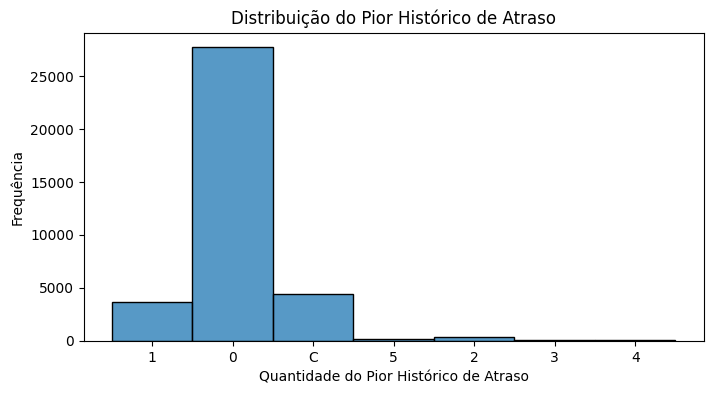

In [255]:
#Histograma para WORST_LATE_HISTORY.
plt.figure(figsize=(8,4))
sns.histplot(df_final["WORST_LATE"])
plt.title('Distribuição do Pior Histórico de Atraso')
plt.xlabel('Quantidade do Pior Histórico de Atraso')
plt.ylabel('Frequência')
plt.show()

O histograma da **Distribuição do Pior Histórico de Atraso (WORST_LATE_HISTORY)** tem um pico proeminente no valor 1 (correspondente a atrasos de 1 a 29 dias). O valor 0 (sem risco) também é significativo. Há uma diminuição acentuada para atrasos mais graves (valores 2 a 6), indicando que a maioria dos clientes que apresentam algum atraso, tem atrasos leves.

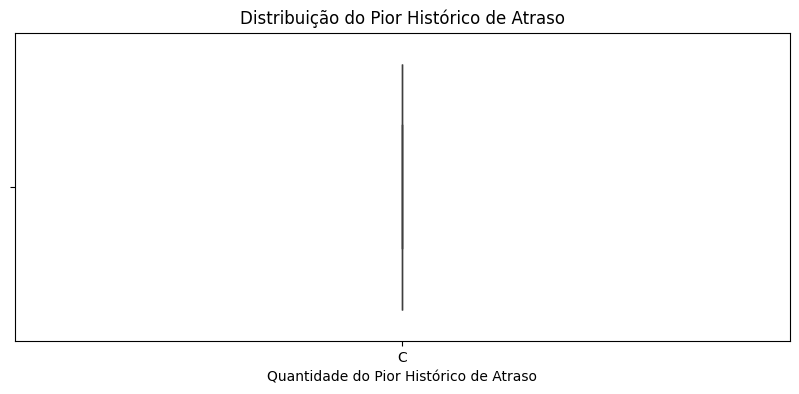

In [ ]:
#Boxplot para STATUS_ON_TIME.

plt.figure(figsize=(10,4))
sns.boxplot(x=df_final["WORST_LATE"])
plt.title('Distribuição do Pior Histórico de Atraso')
plt.xlabel('Quantidade do Pior Histórico de Atraso')
plt.show()

O *boxplot* da **Distribuição do Pior Histórico de Atraso (WORST_LATE_HISTORY)** mostra que a mediana do pior atraso é 1 (1-29 dias). A maioria dos dados está concentrada entre 0 e 1. Os valores 2 a 6 são mostrados como *outliers*, confirmando que os atrasos mais graves são menos frequentes e representam eventos extremos no histórico de crédito.

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [ ]:
#Preparar DataFrame para a matriz de correlação
df_corr = df_final.copy()

# Mapear variáveis categóricas binárias para numéricas.
df_corr["CODE_GENDER"] = df_corr["CODE_GENDER"].map({"M": 1, "F": 0})
df_corr["FLAG_OWN_CAR"] = df_corr["FLAG_OWN_CAR"].map({"Y": 1, "N": 0})
df_corr["FLAG_OWN_REALTY"] = df_corr["FLAG_OWN_REALTY"].map({"Y": 1, "N": 0})

# Identificar colunas categóricas restantes que não são binárias
categorical_cols_to_encode = [
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'
]

# Aplicar One-Hot Encoding para as variáveis categóricas restantes
df_encoded_cols = pd.get_dummies(df_corr[categorical_cols_to_encode], prefix=categorical_cols_to_encode)

# Juntar as colunas codificadas ao df_corr e remover as colunas originais
df_corr = pd.concat([df_corr.drop(columns=categorical_cols_to_encode), df_encoded_cols], axis=1)

# Selecionar as colunas numéricas para a matriz de correlação, incluindo as que foram mapeadas para numéricas
# e as novas variáveis do histórico de crédito, a variável alvo e as recém-codificadas.
numerical_cols = [
    "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "CNT_CHILDREN",
    "AMT_INCOME_TOTAL","YEARS_BIRTH", "YEARS_EMPLOYED", "IS_INACTIVE",
    "CNT_FAM_MEMBERS", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL",
    "LATE_3M", "LATE_6M", "LATE_9M", "LATE_12M", "WORST_LATE","LAST_LATE",
    "HIST_LENGTH", "TOTAL_LATES", "LATE_RATE",
 
] + list(df_encoded_cols.columns)

# Filtrar df_corr para incluir apenas as colunas numéricas selecionadas
df_numerical_corr = df_corr[numerical_cols]

In [ ]:
# Calcular a correlação de todas as variáveis com a variável alvo 'IS_BAD_PAYER'
correlations_with_target = df_numerical_corr.corrwith(df_numerical_corr['IS_BAD_PAYER']).sort_values(ascending=False)

# Excluir a correlação da própria variável alvo consigo mesma
correlations_with_target = correlations_with_target.drop('IS_BAD_PAYER')

plt.figure(figsize=(12, 15))
sns.barplot(x=correlations_with_target.values, y=correlations_with_target.index, palette='coolwarm')
plt.title('Correlação de Variáveis com IS_BAD_PAYER')
plt.xlabel('Coeficiente de Correlação')
plt.ylabel('Variáveis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

KeyError: 'IS_BAD_PAYER'

Gerado o gráfico de barras para conter todas as variáveis e visualizar as correlações com a variável alvo 'IS_BAD_PAYER." Observamos que 'WORST_LATE_HISTORY" tem a correlação mais forte, seguida por 'STATUS-LATED'.  

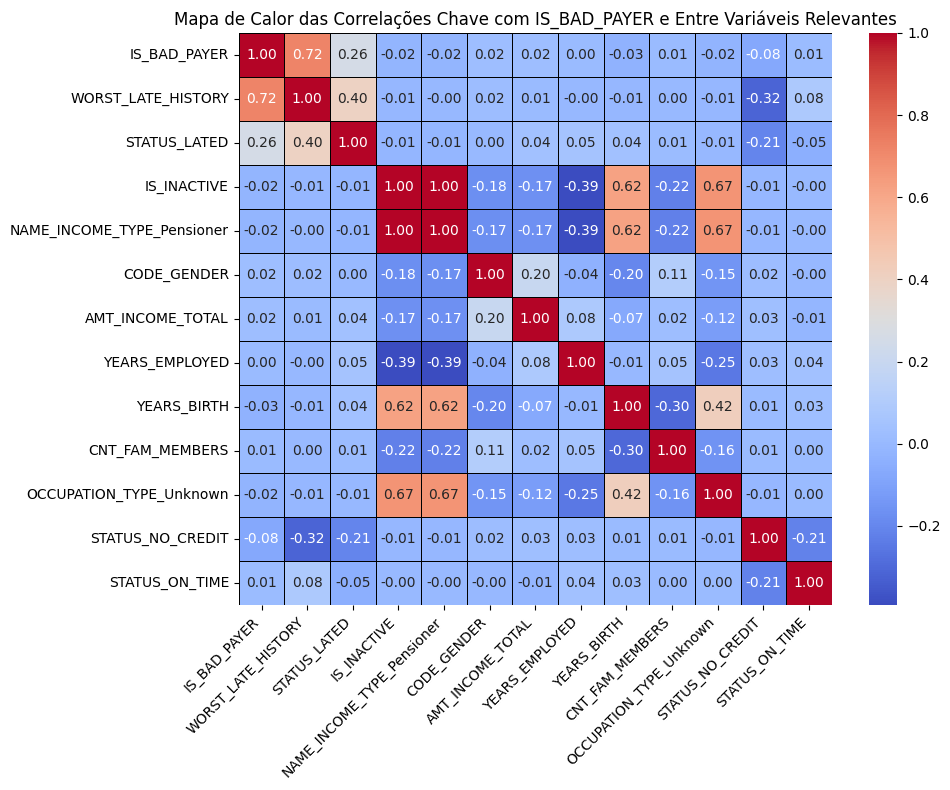

In [ ]:
#Colunas relevantes para a criação da matriz de correlação.
relevant_cols = [
    'IS_BAD_PAYER', #Variável alvo
    'WORST_LATE_HISTORY',
    'STATUS_LATED',
    'IS_INACTIVE',
    'NAME_INCOME_TYPE_Pensioner',
    'CODE_GENDER',
    'AMT_INCOME_TOTAL',
    'YEARS_EMPLOYED',
    'YEARS_BIRTH',
    'CNT_FAM_MEMBERS',
    'OCCUPATION_TYPE_Unknown',
    'STATUS_NO_CREDIT',
    'STATUS_ON_TIME'

]

# Calcular a matriz de correlação para as variáveis selecionadas
correlation_matrix = df_numerical_corr[relevant_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Mapa de Calor das Correlações Chave com IS_BAD_PAYER e Entre Variáveis Relevantes')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

A análise das correlações das variáveis com `IS_BAD_PAYER` (ser mau pagador) revela os seguintes insights principais:

*   **Correlações Positivas Mais Fortes:**
    *   `WORST_LATE_HISTORY`: Esta é a variável com a correlação mais forte e positiva (0.72). Isso corrobora a expectativa de que um histórico de atrasos graves está ligado à classificação de mau pagador.
    *   `STATUS_LATED`: Com uma correlação positiva de 0.26, um maior número de meses com status de atraso (`STATUS_LATED`) está diretamente relacionado a ser classificado como mau pagador.

*   **Correlações Negativas:**
    *   `IS_INACTIVE`: Há uma correlação negativa muito fraca (-0.02) com `IS_BAD_PAYER`. Isso sugere que indivíduos inativos (aposentados/pensionistas, que foram marcados com `IS_INACTIVE=1`) tendem a ter uma probabilidade ligeiramente menor de ser um mau pagador.
    *   `NAME_INCOME_TYPE_Pensioner`: Esta categoria (indivíduos com renda de aposentadoria/pensão) tem uma correlação negativa muito fraca (-0.02) com `IS_BAD_PAYER`, o que está alinhado com a correlação de `IS_INACTIVE`.
    *   `STATUS_NO_CREDIT`: Uma correlação negativa (-0.08) indica que quanto maior o número de meses sem empréstimo, menor a chance de ser um mau pagador.

*   **Correlações Muito Fracas (Próximas de Zero):**
    *   `STATUS_ON_TIME`: Com uma correlação de 0.01, indica uma relação muito fraca e ligeiramente positiva com `IS_BAD_PAYER`. Pagamentos em dia têm uma associação mínima com a classificação de mau pagador.
    *   `CODE_GENDER`: Possui uma correlação muito fraca e positiva (0.02) com `IS_BAD_PAYER`, indicando que o gênero, por si só, não é um forte preditor.
    *   `AMT_INCOME_TOTAL`: A correlação é de 0.02, o que significa que, neste conjunto de dados, a renda total não demonstra uma relação linear significativa com `IS_BAD_PAYER`.
    *   `YEARS_EMPLOYED`: A correlação é de 0.00, sugerindo que os anos de emprego ativo não têm uma relação linear forte com `IS_BAD_PAYER`.
    *   `YEARS_BIRTH`: A correlação é -0.03, indicando uma relação linear muito fraca e negativa.
     *   `OCCUPATION_TYPE_Unknow`: Possui uma correlação muito fraca e positiva (0.02) com `IS_BAD_PAYER`, indicando que a falta de informação desse registro, por si só, não é um forte preditor.
     *   `CNT_FAM_MENBERS`: Possui uma correlação muito fraca e positiva (0.01) com `IS_BAD_PAYER`. Quantidade de menbros familiares não tem relação significativa com 'IS-BAD-PAYER'.


**Conclusão da Correlação:**
As variáveis relacionadas ao histórico de atraso (`WORST_LATE_HISTORY`, `STATUS_LATED`) são as que possuem maior poder preditivo para identificar um mau pagador. É importante notar que muitas outras variáveis apresentam correlações muito próximas de zero, indicando que não são fortes preditores lineares de `IS_BAD_PAYER` por si só.

## 4. Outliers

**Interpretação:** _remover, winsorizar ou manter? Justifique._

In [ ]:
# Identificar colunas numéricas para análise de outliers
numerical_cols_for_outlier_check = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Excluir colunas já tratadas ou que não fazem sentido para detecção de outliers por IQR
# 'ID' é um identificador
# 'DAYS_BIRTH' e 'DAYS_EMPLOYED' foram transformadas em 'YEARS_BIRTH' e 'YEARS_EMPLOYED'
# 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'IS_INACTIVE', 'IS_BAD_PAYER' são binárias ou flags
excluded_cols = [
    'ID', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE',
    'FLAG_PHONE', 'FLAG_EMAIL', 'IS_INACTIVE', 'IS_BAD_PAYER',
]
numerical_cols_for_outlier_check = [
    col for col in numerical_cols_for_outlier_check if col not in excluded_cols
]

print("Análise de Outliers para as seguintes colunas:", numerical_cols_for_outlier_check)
print("\n" + "-"*50 + "\n")

outlier_summary = {}

for col in numerical_cols_for_outlier_check:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_low = df_final[df_final[col] < lower_bound]
    outliers_high = df_final[df_final[col] > upper_bound]

    num_outliers = len(outliers_low) + len(outliers_high)
    total_rows = len(df_final)
    percentage_outliers = (num_outliers / total_rows) * 100

    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': num_outliers,
        'Percentage of Outliers': percentage_outliers
    }

    print(f"Variável: {col}")
    print(f"  Q1 (25º percentil): {Q1:.2f}")
    print(f"  Q3 (75º percentil): {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Limite Inferior (lower_bound): {lower_bound:.2f}")
    print(f"  Limite Superior (upper_bound): {upper_bound:.2f}")
    print(f"  Número de outliers: {num_outliers}")
    print(f"  Proporção de outliers: {percentage_outliers:.2f}%")

    if num_outliers > 0:
        print("  **Outliers detectados! Considerar tratamento (e.g., capping/winsorização) se a proporção for significativa.**")
    else:
        print("  Nenhum outlier detectado pela regra do IQR.")
    print("\n" + "-"*50 + "\n")

Análise de Outliers para as seguintes colunas: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'YEARS_BIRTH', 'YEARS_EMPLOYED', 'TOTAL_MOUNTHS_OBSERVED', 'STATUS_LATED', 'STATUS_ON_TIME', 'STATUS_NO_CREDIT', 'WORST_LATE_HISTORY']

--------------------------------------------------

Variável: CNT_CHILDREN
  Q1 (25º percentil): 0.00
  Q3 (75º percentil): 1.00
  IQR: 1.00
  Limite Inferior (lower_bound): -1.50
  Limite Superior (upper_bound): 2.50
  Número de outliers: 508
  Proporção de outliers: 1.39%
  **Outliers detectados! Considerar tratamento (e.g., capping/winsorização) se a proporção for significativa.**

--------------------------------------------------

Variável: AMT_INCOME_TOTAL
  Q1 (25º percentil): 121500.00
  Q3 (75º percentil): 225000.00
  IQR: 103500.00
  Limite Inferior (lower_bound): -33750.00
  Limite Superior (upper_bound): 380250.00
  Número de outliers: 1529
  Proporção de outliers: 4.19%
  **Outliers detectados! Considerar tratamento (e.g., capping/winsori

As variáveis 'WORST_LATE_HISTORY', 'STATUS_NO_CREDIT', 'STATUS_ON_TIME', 'STATUS_LATED' não serão suavizadas nem removidas, porque queremos que o modelo seja capaz de identificar o comportamento muito fora do padrão. Queremos que o modelo seja capaz de aprender o que é um cliente de alto risco. Será mantido os dados da variável 'YEARS_EMPLOYED, porque um cliente com muitos anos de emprego sugere um preditor de bom pagador.

Tratamento de Outliers para CNT_CHILDREN e CNT_FAM_MEMBERS
Conforme a análise de outliers via IQR, as variáveis CNT_CHILDREN e CNT_FAM_MEMBERS possuem uma pequena, mas notável, porcentagem de valores extremos. Para garantir que esses valores não distorçam a modelagem, aplicaremos a técnica de capping. Essa técnica substitui os valores abaixo do limite inferior pelo próprio limite inferior (Q1 - 1.5 * IQR) e os valores acima do limite superior pelo limite superior (Q3 + 1.5 * IQR). Isso restringe os valores dentro de um intervalo mais razoável, preservando a maioria dos dados e reduzindo a influência dos outliers.

Estatísticas descritivas de CNT_CHILDREN após o capping:


count    36457.000000
mean         0.418959
std          0.688709
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          2.500000
Name: CNT_CHILDREN, dtype: float64

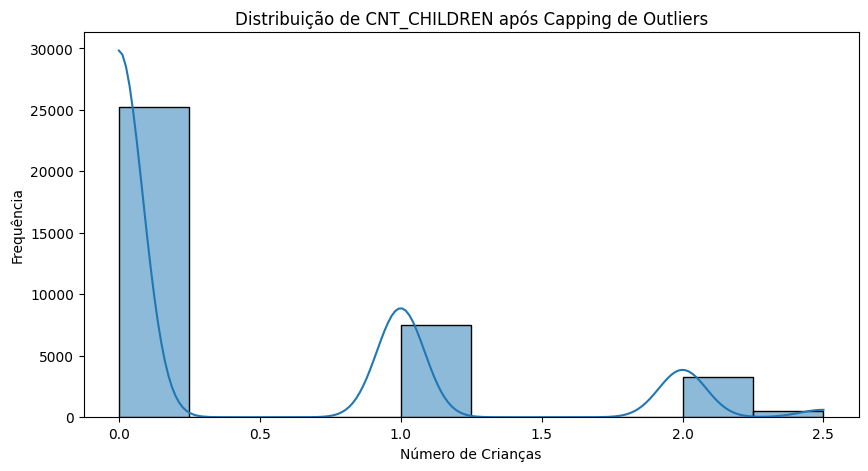

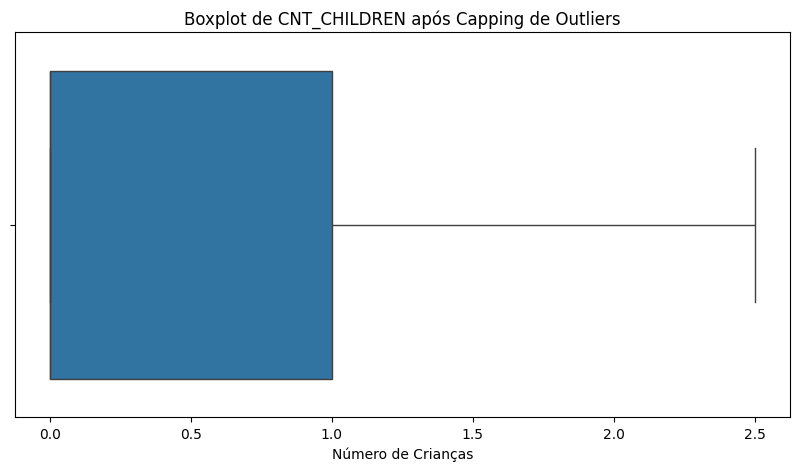

In [ ]:
# Aplicar capping para CNT_CHILDREN
lower_bound_children = outlier_summary['CNT_CHILDREN']['Lower Bound']
upper_bound_children = outlier_summary['CNT_CHILDREN']['Upper Bound']

df_final['CNT_CHILDREN'] = np.where(
    df_final['CNT_CHILDREN'] < lower_bound_children, lower_bound_children,
    np.where(df_final['CNT_CHILDREN'] > upper_bound_children, upper_bound_children,
             df_final['CNT_CHILDREN']
    )
)

print("Estatísticas descritivas de CNT_CHILDREN após o capping:")
display(df_final['CNT_CHILDREN'].describe())

# Visualizar a distribuição após o tratamento
plt.figure(figsize=(10, 5))
sns.histplot(df_final['CNT_CHILDREN'], bins=10, kde=True)
plt.title('Distribuição de CNT_CHILDREN após Capping de Outliers')
plt.xlabel('Número de Crianças')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final['CNT_CHILDREN'])
plt.title('Boxplot de CNT_CHILDREN após Capping de Outliers')
plt.xlabel('Número de Crianças')
plt.show()

Com o capping aplicado, a variável CNT_CHILDREN agora tem seus valores extremos limitados. O histograma e o boxplot mostram uma distribuição mais concentrada, eliminando os outliers que estavam muito além dos limites do IQR. Isso torna a variável mais robusta para análises e modelagens subsequentes.


Estatísticas descritivas de CNT_FAM_MEMBERS após o capping:


count    36457.000000
mean         2.187783
std          0.869257
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          4.500000
Name: CNT_FAM_MEMBERS, dtype: float64

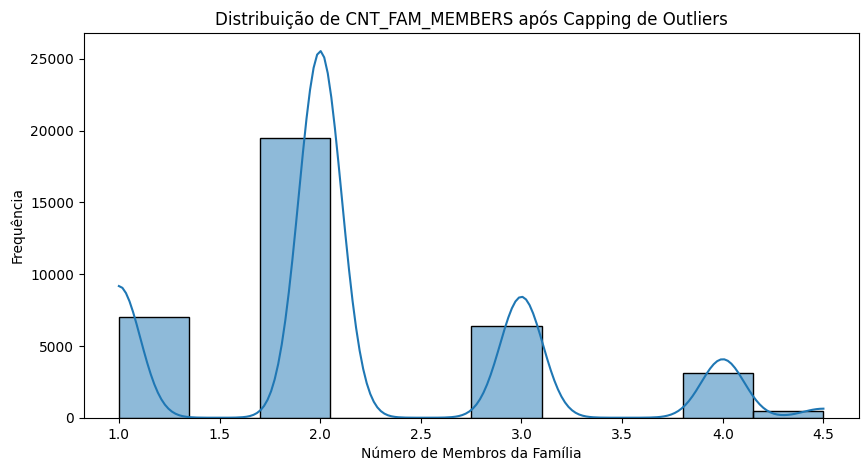

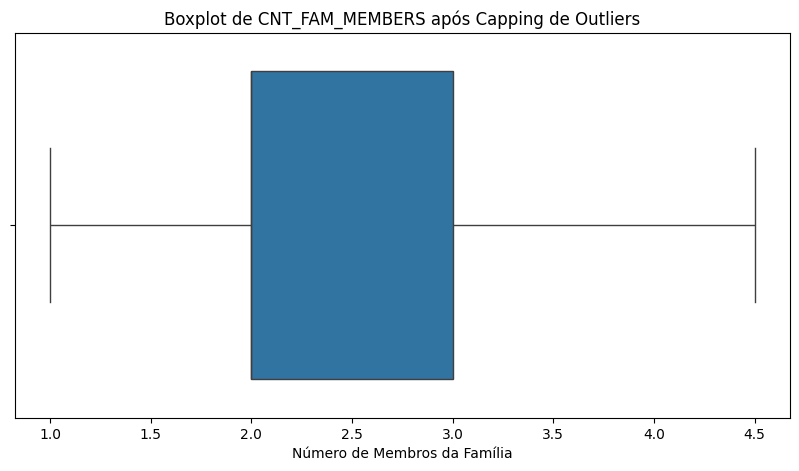

In [ ]:
# Aplicar capping para CNT_FAM_MEMBERS
lower_bound_fam = outlier_summary['CNT_FAM_MEMBERS']['Lower Bound']
upper_bound_fam = outlier_summary['CNT_FAM_MEMBERS']['Upper Bound']

df_final['CNT_FAM_MEMBERS'] = np.where(
    df_final['CNT_FAM_MEMBERS'] < lower_bound_fam, lower_bound_fam,
    np.where(df_final['CNT_FAM_MEMBERS'] > upper_bound_fam, upper_bound_fam,
             df_final['CNT_FAM_MEMBERS']
    )
)

print("Estatísticas descritivas de CNT_FAM_MEMBERS após o capping:")
display(df_final['CNT_FAM_MEMBERS'].describe())

# Visualizar a distribuição após o tratamento
plt.figure(figsize=(10, 5))
sns.histplot(df_final['CNT_FAM_MEMBERS'], bins=10, kde=True)
plt.title('Distribuição de CNT_FAM_MEMBERS após Capping de Outliers')
plt.xlabel('Número de Membros da Família')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final['CNT_FAM_MEMBERS'])
plt.title('Boxplot de CNT_FAM_MEMBERS após Capping de Outliers')
plt.xlabel('Número de Membros da Família')
plt.show()

Os outliers da variável CNT_FAM_MEMBERS foram tratados. As visualizações confirmam que os valores agora se encontram dentro dos limites definidos pelo IQR, o que contribui para uma melhor representação da população e um desempenho mais estável em modelos de Machine Learning. Ambas as variáveis estão agora mais limpas e preparadas para as próximas etapas.

Tratamento de AMT_INCOME_TOTAL com Transformação Logarítmica.
A variável AMT_INCOME_TOTAL possui uma distribuição assimétrica à direita (cauda longa à direita), com a presença de outliers de alta renda. Para tornar essa distribuição mais próxima de uma normal e reduzir a influência desses valores extremos em modelos de Machine Learning, aplicaremos uma transformação logarítmica (np.log1p). Esta transformação é especialmente útil para dados que são estritamente positivos e que exibem uma grande variação, comprimindo os valores maiores e expandindo os menores.

Estatísticas descritivas de AMT_INCOME_TOTAL_LOG após transformação logarítmica:


count    36457.000000
mean        12.018808
std          0.480501
min         10.203629
25%         11.707678
50%         11.967187
75%         12.323860
max         14.269766
Name: AMT_INCOME_TOTAL_LOG, dtype: float64

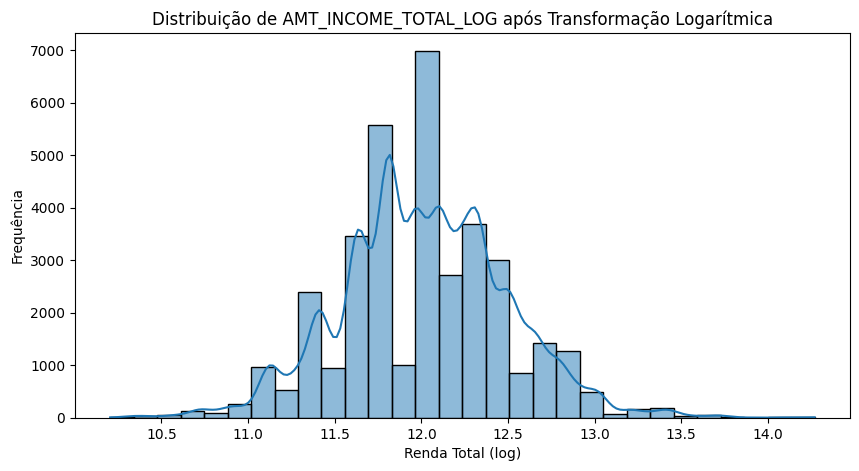

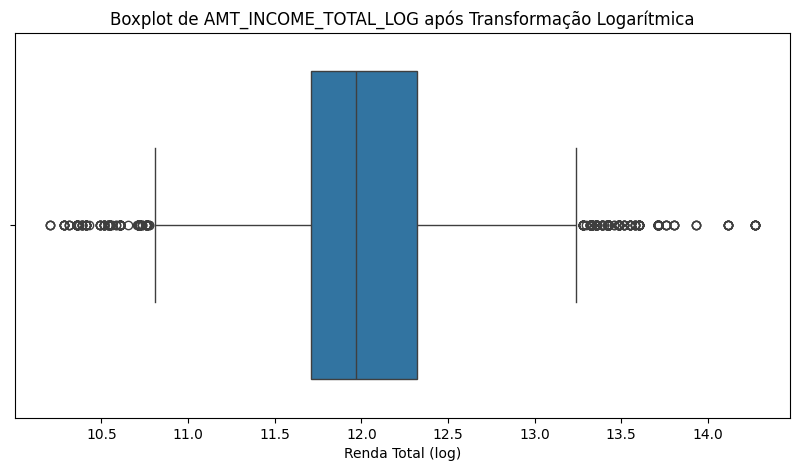

In [ ]:
# Aplicar transformação logarítmica (log1p para lidar com valores zero, se existirem)
df_final['AMT_INCOME_TOTAL_LOG'] = np.log1p(df_final['AMT_INCOME_TOTAL'])

print("Estatísticas descritivas de AMT_INCOME_TOTAL_LOG após transformação logarítmica:")
display(df_final['AMT_INCOME_TOTAL_LOG'].describe())

# Visualizar a distribuição após o tratamento
plt.figure(figsize=(10, 5))
sns.histplot(df_final['AMT_INCOME_TOTAL_LOG'], bins=30, kde=True)
plt.title('Distribuição de AMT_INCOME_TOTAL_LOG após Transformação Logarítmica')
plt.xlabel('Renda Total (log)')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final['AMT_INCOME_TOTAL_LOG'])
plt.title('Boxplot de AMT_INCOME_TOTAL_LOG após Transformação Logarítmica')
plt.xlabel('Renda Total (log)')
plt.show()

Após a aplicação da transformação logarítmica (np.log1p), a distribuição de AMT_INCOME_TOTAL (agora AMT_INCOME_TOTAL_LOG) tornou-se visivelmente mais simétrica e próxima de uma distribuição normal. O histograma mostra uma forma mais equilibrada, e o boxplot indica uma redução significativa na dispersão dos outliers, que foram trazidos para mais perto do corpo principal da distribuição. Essa transformação é fundamental para garantir que a variável contribua de forma mais eficaz e menos enviesada nos modelos preditivos.

## 5. Balanceamento de classes

**Interpretação:** _qual a proporção entre as classes e o que isso implica na escolha das métricas?_

Com a criação da variável IS_BAD_PAYER, observamos que a maioria dos clientes é classificada como 'bom pagador' (0) 88,28%, enquanto uma minoria significativa é classificada como 'mau pagador' (1) 11,77%.

Implicações para a escolha das métricas:

Em um cenário de classes desbalanceadas, métricas como a acurácia (accuracy) podem ser enganosas, pois um modelo pode atingir alta acurácia simplesmente prevendo a classe majoritária na maioria das vezes. Por exemplo, se 90% dos clientes são bons pagadores, um modelo que sempre prevê 'bom pagador' terá 90% de acurácia, mas seria inútil para identificar os maus pagadores.

Para avaliar o desempenho do modelo de forma mais adequada, devemos considerar métricas que são mais robustas ao desbalanceamento, como:

**Precisão (Precision)**: A proporção de identificações positivas corretas (dos que o modelo classificou como mau pagador, quantos realmente são).

**Recall (Sensibilidade)**: A proporção de positivos reais que foram identificados corretamente (dos que são realmente maus pagadores, quantos o modelo conseguiu detectar).

**F1-Score:** A média harmônica da precisão e do recall, útil quando se busca um equilíbrio entre as duas.

**AUC-ROC (Area Under the Receiver Operating Characteristic Curve):** Uma métrica que avalia a capacidade do modelo de distinguir entre as classes, independentemente do limiar de classificação escolhido.

**Matriz de Confusão:** Para visualizar os True Positives, True Negatives, False Positives e False Negatives.
Na fase de modelagem, técnicas de balanceamento (como oversampling da classe minoritária com SMOTE, undersampling da classe majoritária, ou ajuste de pesos das classes) podem ser aplicadas para mitigar o impacto desse desbalanceamento.

(Obs.: o balanceamento de classes, usando técnicas como oversampling, undersampling ou SMOTE) não foi realizado nesta fase para evitar o vazamento de dados. Será considerado e implementado no Notebbok 03, dentro de um Pipeline. Isso garantirá que as trasnformações de dados seja aplicada de maneira apropriada, prevenindo o vazamento de informações e resultando em uma avaliação de modelo mais justa e confiável).

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._

**Análise Exploratória de Dados: Entendendo o Risco de Crédito**

Nosso objetivo fundamental neste projeto é construir um modelo robusto para prever o risco de crédito, classificando os solicitantes entre "bons pagadores" e "maus pagadores". Para isso, realizamos a Análise Exploratória de Dados (EDA), trabalhando com duas bases de dados df_application, contendo informações demográficas e de emprego dos solicitantes, e df_credit, que detalha o histórico de pagamentos.

#### **1. Consolidação e Preparação dos Dados**

Iniciamos com o df_application, um vasto registro de 438.557 linhas e 18 ariáveis. Um dos primeiros desafios foi o tratamento da variável `OCCUPATION_TYPE, que apresentava um grande número de valores ausentes, preenchidos de forma estratégica com 'Unknown' para preservar a informação. Identificamos também um pequeno número de IDs duplicados com informações conflitantes, e um volume considerável de linhas totalmente idênticas (exceto pelo ID), que foram mantidos para análise contextual posterior.

Paralelamente, o df_credit, com mais de 1 milhão de registros, foi a base para construir o histórico de crédito de cada solicitante. Agregamos esses dados por ID, criando variáveis essenciais como TOTAL_MOUNTHS_OBSERVED (tempo total de observação), STATUS_LATED (meses com atraso), STATUS_ON_TIME (meses em dia), STATUS_NO_CREDIT (meses sem crédito no mês) e WORST_LATE_HISTORY (o pior status de atraso observado). A fusão desses dois conjuntos de dados nos proporcionou uma visão completa de cada solicitante.

#### **2. A Variável Alvo e o Desafio do Desbalanceamento**

Com os dados integrados, construímos nossa variável alvo: IS_BAD_PAYER. Classificamos como 'mau pagador' (1) clientes que, em seu pior histórico, tiveram atrasos superiores a 29 dias (representado por valores > 1 em WORST_LATE_HISTORY); os demais foram categorizados como 'bom pagador' (0).

Esta etapa revelou um achado crítico: um **desbalanceamento severo** na distribuição das classes. Observamos que aproximadamente **88,28%** dos clientes são 'bons pagadores', enquanto apenas **11,72%** são 'maus pagadores'. Este cenário, comum em problemas de risco de crédito, exige uma abordagem cuidadosa na modelagem. Métricas de avaliação tradicionais como a acurácia podem ser enganosas, pois um modelo poderia atingir alta acurácia simplesmente prevendo a classe majoritária.

Para contornar isso, enfatizamos que nosso modelo será avaliado por métricas mais robustas, como **Precisão**, **Recall**, **F1-Score**, **AUC-ROC** e a **Matriz de Confusão**, que nos darão uma visão mais fiel da capacidade do modelo em identificar os 'maus pagadores'. Além disso, destacamos a necessidade de balanceamento de classes,  para garantir que o modelo não seja viesado.

#### **3. Tratamento de Outliers e Transformações de Variáveis Chave**

A qualidade dos dados é fundamental. Em YEARS_EMPLOYED, identificamos valores de `-1000`, que representavam clientes inativos ou pensionistas. Corrigimos isso substituindo por `0` e criamos a variável IS_INACTIVE para capturar essa condição de forma explícita. Outliers em CNT_CHILDREN e CNT_FAM_MEMBERS também foram tratados através da técnica de "capping" baseada no Intervalo Interquartil (IQR), minimizando seu impacto sem distorcer a distribuição principal.

Uma transformação foi aplicada à AMT_INCOME_TOTAL. Dada a sua distribuição altamente assimétrica e a presença de outliers de alta renda, aplicamos uma **transformação logarítmica (`np.log1p`)**. O resultado foi uma distribuição visivelmente mais simétrica e menos suscetível à influência de valores extremos, tornando-a muito mais adequada para o aprendizado de máquina.

#### **4. Principais Insights das Variáveis**

Nossa EDA também nos forneceu insights valiosos sobre o perfil dos solicitantes:

*   **Renda (AMT_INCOME_TOTAL_LOG)**: A maioria concentra-se em faixas de renda média a baixa, com a transformação logarítmica aprimorando a distribuição.
*   **Idade (YEARS_BIRTH)**: A base de clientes é predominantemente jovem a adulta, com a maioria entre 30 e 40 anos, indicando um perfil ativo no mercado de trabalho.
*   **Emprego (YEARS_EMPLOYED)**: Há um pico significativo de clientes com 0 anos de emprego (inativos), decrescendo com o aumento dos anos de serviço.
*   **Gênero (CODE_GENDER)**: Uma predominância feminina na base de dados.
*   **Ocupação (OCCUPATION_TYPE)**: 'Unknown', 'Laborers' e 'Core staff' são as categorias mais comuns.
*   **Posse de Bens**: A maioria dos clientes não possui carro, mas uma parcela significativa possui imóvel.
*   **Educação (NAME_EDUCATION_TYPE)**: 'Secondary / secondary special' e 'Higher education' são os níveis educacionais mais frequentes.
*   **Histórico de Crédito**: A maioria dos clientes possui um histórico de crédito relativamente curto, com poucos atrasos graves, reforçando o desbalanceamento da nossa variável alvo.

#### **Conclusão: Dados Prontos para a Modelagem**

Após a limpeza e transformação nossos dados estão em um estado compreensível. Os desafios de outliers e desbalanceamento de classes foram identificados e tratados. Nas próximas etapas construiremos modelos de Machine Learning eficazes e justos, capazes de prever o risco de crédito com precisão, contribuindo significativamente para a tomada de decisões estratégicas.